<a href="https://colab.research.google.com/github/Salahuddola/Play-Store-App-Analysis/blob/main/playstore_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 1. Introduction & Project Overview

### 📌 Project Context
* **Project Type:** Exploratory Data Analysis (EDA) & Data Storytelling
* **Dataset:** Google Play Store Apps Dataset
* **Domain:** Mobile App Analytics & Digital Product Strategy
* **Primary Objective:** Analyze app performance metrics (Ratings, Installs, Reviews, Pricing) to uncover key factors that drive user engagement, satisfaction, and market success.

### 🛠️ Analytics Tech Stack
* **Environment:** Google Colab
* **Programming Language:** Python
* **Data Manipulation:** Pandas, NumPy
* **Data Visualization:** Matplotlib, Seaborn

### 🎯 Business Value
Providing actionable insights for developers, product managers, and app publishers to optimize category selection, pricing strategies, and user retention.

# 🎯 2. Problem Understanding & Business Context

### 📱 Dataset Overview
The Google Play Store dataset captures operational and performance metrics of thousands of Android applications. It provides detailed metadata including app categories, user ratings, review counts, application size, download volumes (installs), content ratings, and pricing models.

### ❓ Key Business Questions
1. **Market Selection:** Which app categories offer the highest potential for mass reach versus high user satisfaction?
2. **Pricing Strategy:** How does the monetization model (Free vs. Paid) impact overall user ratings and app downloads?
3. **Engagement Drivers:** What is the relationship between user engagement (Reviews) and satisfaction (Ratings)?

### 💡 Why This Analysis is Useful
* **For Developers & Startups:** Helps identify uncrowded "niche" categories with high average ratings to maximize user acquisition and retention.
* **For Product Managers:** Provides baseline benchmarks for pricing, app sizing, and user feature prioritization.
* **For Investors:** Offers data-driven insights into high-yield app categories before allocating capital.

### ⚠️ Key Variables & Constraints
* **Key Target Variable:** `Rating` (Continuous metric representing overall user satisfaction).
* **Supporting Metrics:** `Installs`, `Reviews`, `Price`, `Category`, and `Type` (Free/Paid).
* **Data Constraints:**
  * Presence of non-numeric characters in numerical columns (e.g., `+`, `,`, `$`).
  * Severe skewness in download volumes ranging from single digits to over 1 Billion installs.
  * Potential survival bias (apps with zero downloads or removed apps are omitted).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
df_apps = pd.read_csv('/content/drive/MyDrive/Play Store Data.csv')
df_reviews = pd.read_csv('/content/drive/MyDrive/User Reviews.csv')

In [ ]:
df_apps.head(5)



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In this step, we identify missing values in each column of the dataset. Missing values can affect the accuracy of data analysis and machine learning models. Understanding the number of missing values helps us decide whether to remove them or replace them with appropriate values during the data cleaning process.

In [ ]:
df_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df_apps.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


Duplicate records can lead to biased analysis and inaccurate results. In this step, we check whether the dataset contains any duplicate rows so that they can be removed before further analysis.

In [ ]:
df_apps.duplicated().sum()

np.int64(483)

In [ ]:
df_apps[df_apps.duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
236,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
239,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
261,join.me - Simple Meetings,BUSINESS,4.0,6989,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 16, 2018",4.3.0.508,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643,Wunderlist: To-Do List & Tasks,PRODUCTIVITY,4.6,404610,Varies with device,"10,000,000+",Free,0,Everyone,Productivity,"April 6, 2018",Varies with device,Varies with device
8654,"TickTick: To Do List with Reminder, Day Planner",PRODUCTIVITY,4.6,25370,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"August 6, 2018",Varies with device,Varies with device
8658,ColorNote Notepad Notes,PRODUCTIVITY,4.6,2401017,Varies with device,"100,000,000+",Free,0,Everyone,Productivity,"June 27, 2018",Varies with device,Varies with device
10049,Airway Ex - Intubate. Anesthetize. Train.,MEDICAL,4.3,123,86M,"10,000+",Free,0,Everyone,Medical,"June 1, 2018",0.6.88,5.0 and up


In [ ]:
df_apps = df_apps.drop_duplicates()

In [ ]:
df_apps.duplicated().sum()

np.int64(0)

Handling Missing Values

After removing duplicate records, the next step is to handle missing values. Missing values can reduce the quality of the analysis and may lead to incorrect conclusions. In this project, we will identify the missing values and apply appropriate techniques such as removing records or filling missing values based on the nature of each column.

In [ ]:
df_apps.isnull().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df_apps["Rating"].median()

4.3

In [ ]:
df_apps["Rating"] = df_apps["Rating"].fillna(df_apps["Rating"].median())

In [ ]:
df_apps.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


Filling Missing Values in Categorical Columns

The remaining missing values are present in categorical columns. Since the number of missing records is very small, these values are replaced with the most frequently occurring value (mode). This helps maintain data consistency without removing additional records.

In [ ]:
df_apps["Type"] = df_apps["Type"].fillna(df_apps["Type"].mode()[0])

df_apps["Content Rating"] = df_apps["Content Rating"].fillna(df_apps["Content Rating"].mode()[0])

df_apps["Current Ver"] = df_apps["Current Ver"].fillna(df_apps["Current Ver"].mode()[0])

df_apps["Android Ver"] = df_apps["Android Ver"].fillna(df_apps["Android Ver"].mode()[0])

In [ ]:
df_apps.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


Data Type Conversion

Some columns are stored as text (object) even though they represent numerical values or dates. These columns need to be converted into appropriate data types to perform accurate analysis and visualization.

In [ ]:
df_apps["Reviews"] = pd.to_numeric(df_apps["Reviews"], errors="coerce")

In [ ]:
df_apps["Reviews"].dtype

dtype('float64')

Converting the Installs Column

The Installs column contains special characters such as commas (,) and plus signs (+), which prevent it from being treated as a numeric column. These characters are removed before converting the column into a numeric data type.



In [ ]:
df_apps.iloc[9990]

,10472
App,Life Made WI-Fi Touchscreen Photo Frame
Category,1.9
Rating,19.0
Reviews,NaN
Size,"1,000+"
Installs,Free
Type,0
Price,Everyone
Content Rating,Everyone
Genres,"February 11, 2018"


In [ ]:
df_apps = df_apps.drop(10472)


In [ ]:
df_apps["Installs"] = df_apps["Installs"].str.replace(",", "")
df_apps["Installs"] = df_apps["Installs"].str.replace("+", "", regex=False)
df_apps["Installs"] = pd.to_numeric(df_apps["Installs"])

Converting the Price Column

The Price column contains dollar ($) symbols, which prevent it from being treated as a numeric feature. These symbols are removed, and the column is converted into a numeric data type for further analysis.

In [ ]:
df_apps["Price"] = df_apps["Price"].str.replace("$", "", regex=False)
df_apps["Price"] = pd.to_numeric(df_apps["Price"])

In [ ]:
df_apps["Price"].dtype

dtype('float64')

Cleaning and Converting the Size Column

The Size column contains values in different formats such as megabytes (M), kilobytes (k), and the text "Varies with device". To make the data suitable for analysis, these values are standardized into megabytes (MB), and invalid text values are treated as missing.

In [ ]:
df_apps["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

Standardizing the Size Column

The Size column contains values in different units such as megabytes (M) and kilobytes (k). It also contains the text "Varies with device", which does not represent a numeric value. To standardize the data, kilobytes are converted into megabytes, "Varies with device" is treated as a missing value, and the column is converted into a numeric format.

In [ ]:
# Replace "Varies with device" with NaN
df_apps["Size"] = df_apps["Size"].replace("Varies with device", np.nan)

# Convert KB to MB
df_apps["Size"] = df_apps["Size"].apply(lambda x: str(float(x[:-1]) / 1024) + "M" if isinstance(x, str) and x.endswith("k") else x)

# Remove 'M'
df_apps["Size"] = df_apps["Size"].str.replace("M", "", regex=False)

# Convert to numeric
df_apps["Size"] = pd.to_numeric(df_apps["Size"])

In [ ]:
df_apps["Size"].dtype

dtype('float64')

In [ ]:
df_apps["Size"].isnull().sum()

np.int64(1526)

Converting the Last Updated Column

The Last Updated column is stored as text. It is converted into a datetime format to enable time-based analysis, such as identifying update trends over the years.

In [ ]:
df_apps["Last Updated"] = pd.to_datetime(df_apps["Last Updated"])

In [ ]:
df_apps["Last Updated"].dtype

dtype('<M8[ns]')

In [ ]:
df_apps.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,1526
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
df_apps["Size"] = df_apps["Size"].fillna(df_apps["Size"].median())

Exploring the User Reviews Dataset

Before cleaning the dataset, it is important to examine its structure, data types, and missing values to understand the quality of the data.

In [ ]:
df_reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
df_reviews.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [ ]:
df_reviews.duplicated().sum()

np.int64(33616)

Removing Duplicate Records

The user reviews dataset contains a large number of duplicate records. These duplicates can introduce bias in sentiment analysis and lead to inaccurate results. Therefore, duplicate entries are removed before further processing.

In [ ]:
df_reviews = df_reviews.drop_duplicates()

In [ ]:
df_reviews.duplicated().sum()

np.int64(0)

In [ ]:
df_reviews = df_reviews.dropna()

In [ ]:
df_reviews.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29692 entries, 0 to 64230
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     29692 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29692 non-null  object 
 3   Sentiment_Polarity      29692 non-null  float64
 4   Sentiment_Subjectivity  29692 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB


Merging the Datasets

The Play Store dataset contains application details, while the User Reviews dataset contains customer feedback and sentiment information. Both datasets are merged using the App column to create a unified dataset for comprehensive analysis.

In [ ]:
merged_df = pd.merge(df_apps, df_reviews, on="App", how="inner")

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40414 entries, 0 to 40413
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     40414 non-null  object        
 1   Category                40414 non-null  object        
 2   Rating                  40414 non-null  float64       
 3   Reviews                 40414 non-null  float64       
 4   Size                    40414 non-null  float64       
 5   Installs                40414 non-null  int64         
 6   Type                    40414 non-null  object        
 7   Price                   40414 non-null  float64       
 8   Content Rating          40414 non-null  object        
 9   Genres                  40414 non-null  object        
 10  Last Updated            40414 non-null  datetime64[ns]
 11  Current Ver             40414 non-null  object        
 12  Android Ver             40414 non-null  object

In [ ]:
merged_df.shape

(40414, 17)

In [ ]:
merged_df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
4,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


**EDA - 1: Distribution of App Ratings**
Distribution of App Ratings

This visualization shows the distribution of application ratings in the Google Play Store dataset. It helps identify whether most applications receive high ratings or low ratings and provides an overall understanding of rating patterns.



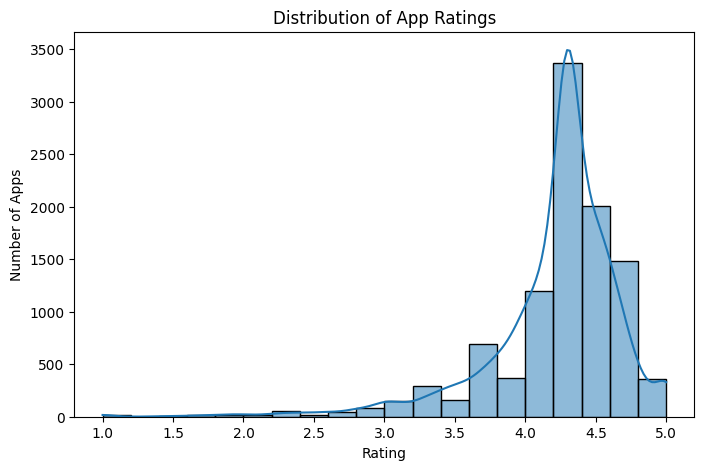

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_apps["Rating"], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

Most applications have ratings between 4.0 and 4.5, indicating that a large proportion of apps on the Google Play Store receive positive user feedback.

**EDA 2: Distribution of App Categories**

Distribution of Applications Across Categories

This visualization shows the number of applications available in each category on the Google Play Store. It helps identify the most popular categories based on the number of published applications.

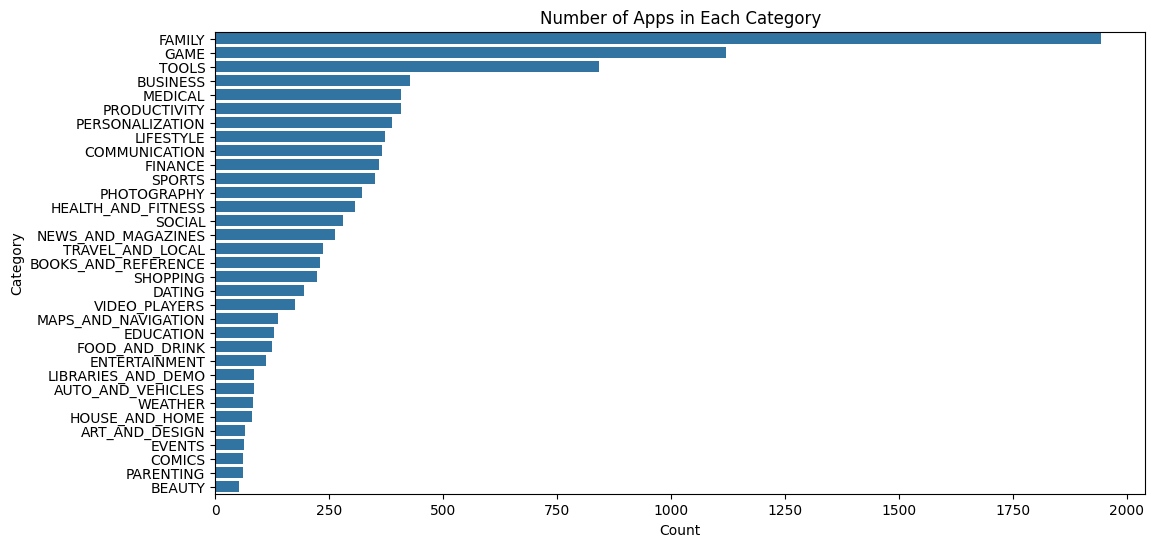

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y=df_apps["Category"],
    order=df_apps["Category"].value_counts().index
)

plt.title("Number of Apps in Each Category")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

**INSIGHTS**

1.The Family category contains the highest number of applications on the Google Play Store.

2.Game is the second-largest category, indicating strong developer interest in entertainment applications.

3.Categories such as Tools, Business, and Medical also have a significant number of applications.

4.Categories like Beauty, Comics, and Events have comparatively fewer applications, suggesting lower representation in the Play Store.






**EDA 3: Free vs Paid Apps**

Distribution of Free and Paid Applications

This visualization compares the number of free and paid applications available on the Google Play Store. It helps understand the business model preferred by app developers.

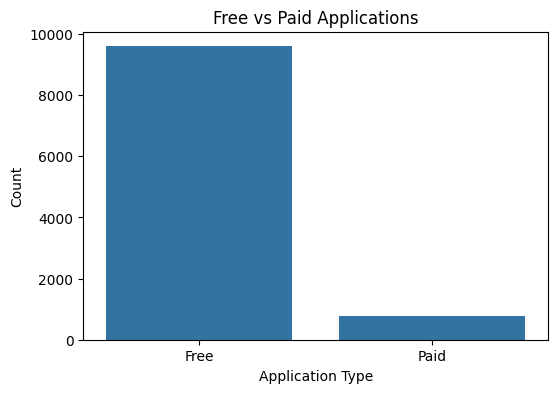

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x="Type", data=df_apps)

plt.title("Free vs Paid Applications")
plt.xlabel("Application Type")
plt.ylabel("Count")

plt.show()

##**2. Bivariate Analysis**
> Analyzing relationships between two different variables to uncover key patterns relative to app success and user engagement.

### **EDA 4: Average Rating by Category (Bar Plot)**

**Average Rating by Category**

Business Question

Which app categories have the highest average user ratings on the Google Play Store?

Why this Visualization?

A bar chart is an effective way to compare the average ratings of different app categories. It helps identify which categories consistently receive better user feedback.

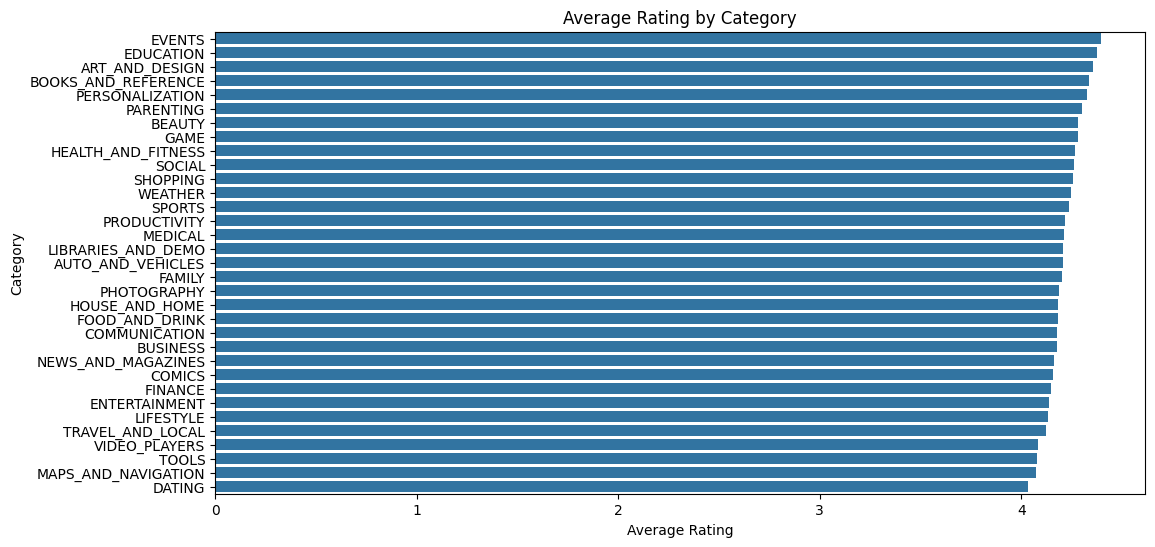

In [ ]:
# Calculate average rating for each category
avg_rating = (
    df_apps.groupby("Category")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.show()

#### Key Insight
* **Top Performers:** Niche and specialized categories like **EVENTS**, **EDUCATION**, **ART_AND_DESIGN**, and **BOOKS_AND_REFERENCE** achieve the highest average ratings (> 4.3).
* **Consistently High Ratings:** Most categories maintain high average ratings clustered tightly between 4.0 and 4.4, showing high overall satisfaction across the store.
* **Lower Relative Ratings:** Broad utility and transactional categories like **DATING**, **MAPS_AND_NAVIGATION**, and **TOOLS** appear near the bottom with lower relative averages due to higher user friction and technical issues.

#### Business Recommendation
* **Target High-Satisfaction Niches:** Entering specialized categories like Education or Art & Design provides a higher baseline of user approval, as users in these domains tend to rate more favorably.
* **Focus on UX in Functional Categories:** If developing apps in utility or transactional domains (like Navigation or Dating), prioritize seamless performance, offline support, and low latency to overcome common user pain points and boost low average ratings

### 🔹 EDA 5: Top 10 Categories by Total Installs
* **Target Focus:** Category vs. Total Installs

#### Business Question
Which app categories generate the highest cumulative volume of user installations on the Google Play Store?

#### Why this Visualization?
A horizontal bar chart is ideal for ranking top-performing categorical features by aggregate volume (`Installs`), helping differentiate mass-market demand from niche segments.



/tmp/ipykernel_1078/2155643969.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


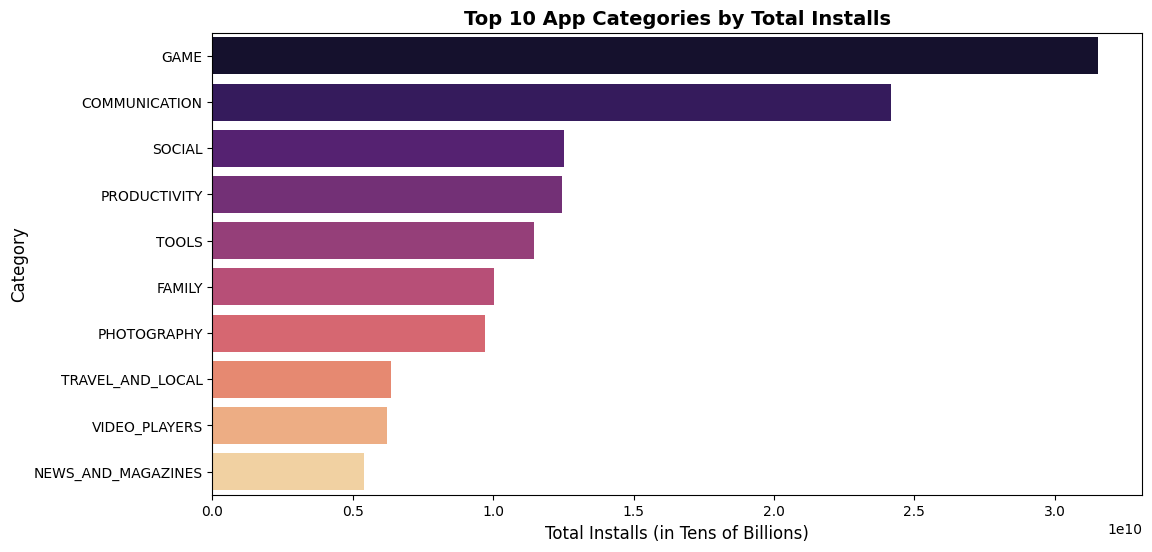

In [ ]:

# Calculate total installs for each category and select top 10
top_installs = (
    df_apps.groupby("Category")["Installs"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_installs.values,
    y=top_installs.index,
    palette="magma"
)

plt.title("Top 10 App Categories by Total Installs", fontsize=14, fontweight='bold')
plt.xlabel("Total Installs (in Tens of Billions)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.show()

#### Key Insight
* **Dominant Leader:** **GAME** is the undisputed leader in total user downloads, significantly outperforming all other categories on the Play Store.
* **Mass-Market Appeal:** **COMMUNICATION**, **SOCIAL**, and **PRODUCTIVITY** categories form the second tier of heavy download volumes, driven by global essential utilities and daily active user habits.
* **Utility & Media Consumption:** **TOOLS**, **FAMILY**, **PHOTOGRAPHY**, **TRAVEL_AND_LOCAL**, and **VIDEO_PLAYERS** round out the top 10, highlighting a strong consumer demand for media creation and system utility apps.

#### Business Recommendation
* **High Reach, High Competition:** Entering the Game or Communication market guarantees access to a massive audience, but requires heavy capital for user acquisition (UA) and retention due to market saturation.
* **Monetization Strategy:** For apps in high-install categories like Games or Social, **In-App Advertisements (IAA)** and **In-App Purchases (IAP)** are the most viable monetization models, whereas Freemium models suit Productivity tools best.

# 🧩 3. Multivariate Analysis
> Analyzing interactions between three or more variables simultaneously to uncover multi-dimensional relationships and deeper strategic insights.

---

### 🔹 EDA 7: Category vs. Installs vs. Average Rating
* **Target Focus:** Category + Installs + Rating (3 Variables)

#### Business Question
Which app categories generate high download volumes (Installs) while successfully maintaining high user satisfaction (Rating)?

#### Why this Visualization?
A bubble-style scatter plot maps three dimensions onto a single graph: X-axis represents average rating, Y-axis represents total installs, and the position/labels show the categories. This instantly separates high-performing categories from high-risk ones

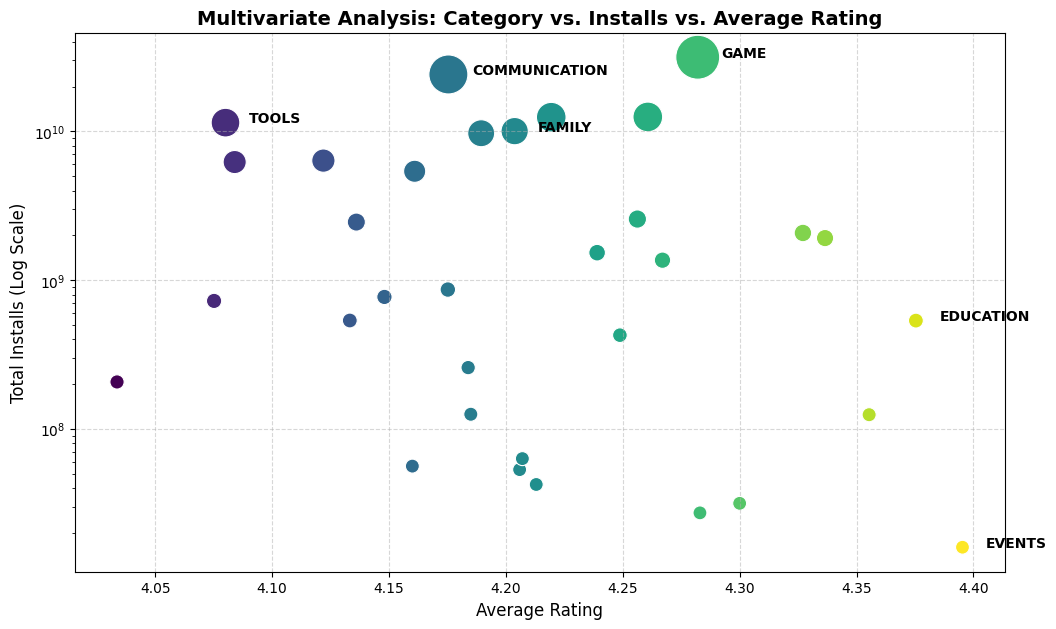

In [ ]:
# Aggregate average rating and total installs per category
cat_multivar = df_apps.groupby("Category").agg({
    "Rating": "mean",
    "Installs": "sum"
}).reset_index()

# Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=cat_multivar,
    x="Rating",
    y="Installs",
    size="Installs",
    sizes=(100, 1000),
    hue="Rating",
    palette="viridis",
    legend=False
)

# Annotate top categories on the plot
for i in range(len(cat_multivar)):
    # Annotate key prominent categories for clarity
    if cat_multivar['Category'][i] in ['GAME', 'COMMUNICATION', 'TOOLS', 'EVENTS', 'EDUCATION', 'FAMILY']:
        plt.text(
            cat_multivar['Rating'][i] + 0.01,
            cat_multivar['Installs'][i],
            cat_multivar['Category'][i],
            fontsize=10,
            weight='bold'
        )

plt.yscale("log") # Log scale to handle huge install variations
plt.title("Multivariate Analysis: Category vs. Installs vs. Average Rating", fontsize=14, fontweight='bold')
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Total Installs (Log Scale)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### Key Insight
* **High Demand, High Rating Sweet Spot:** **GAME** and **COMMUNICATION** sit at the top-right quadrant, representing categories with massive total installs ($> 10^{10}$) while successfully maintaining high user satisfaction ratings ($> 4.3$).
* **Niche Excellence:** **EDUCATION** appears on the far-right with a very high average rating ($> 4.4$), despite having lower total installation volume compared to Games, indicating high quality and user satisfaction in specialized markets.
* **Functional Friction:** **TOOLS** shows a high volume of installs but sits further to the left with a lower average rating, highlighting that high utility doesn't automatically translate to high customer ratings due to performance issues or intrusive ads.

#### Business Recommendation
* **Target Quadrant Strategy:**
  - For **Maximum Scale**, invest in *Game* or *Communication* categories, but ensure strong feature differentiation.
  - For **High User Retention & Brand Loyalty**, invest in *Education*, where users are naturally more satisfied and rate apps higher.
* **Quality Optimization:** Developers in the *Tools* space should focus on reducing intrusive ads and fixing technical bugs to shift their app ratings toward the right quadrant (4.3+).

# 💼 6. Business Interpretation & Data Storytelling
> Translating analytical findings into actionable business strategies and executive takeaways.

### 📌 Key Strategic Findings
1. **The 'Sweet Spot' Categories:**
   * **Games** and **Communication** categories drive massive install volumes while maintaining high average ratings (>4.3). They represent high-demand, high-satisfaction markets.
2. **Niche Category Opportunities:**
   * **Education**, **Events**, and **Health & Fitness** show high average user satisfaction despite moderate install counts. Users in these categories are easier to retain.
3. **The Utility Pain Point:**
   * **Tools** and **Navigation** categories see billions of installs but suffer from lower average ratings. Intrusive ads and performance bugs hamper user experience.

### 🎯 Actionable Stakeholder Recommendations
* **For New Developers:** Enter niche segments like *Education* or *Art & Design* for faster user adoption, or differentiate aggressively if entering *Games*.
* **For Product Managers in Utility Apps:** Focus on UI/UX optimization and non-intrusive monetization (fewer pop-up ads) to raise ratings above the 4.0 threshold.
* **For Monetization Teams:** Free apps in mass categories (*Games/Social*) should rely on In-App Purchases (IAP) and targeted ads, while niche apps perform better with Freemium/Subscription models.

# 🧪 7. Testing, Notebook Quality & Technical Challenges

### 🧹 Technical Challenges & Data Cleaning Solutions
1. **Corrupted & String Formatted Data:**
   * **Challenge:** The `Installs` column contained symbols like `+` and `,` (e.g., `10,000,000+`), and the `Price` column included `$` signs, making numerical and arithmetic operations impossible.
   * **Solution:** Applied Pandas string operations (`str.replace()`) and Regular Expressions (Regex) to strip non-numeric characters and cast the cleaned values into `float` and `int` data types.

2. **Handling Missing & Duplicate Data:**
   * **Challenge:** The dataset contained duplicate app listings and missing values (`NaN`) in the `Rating` column, which could bias aggregations.
   * **Solution:** Dropped duplicate records based on unique app names and applied systematic missing-value handling (filtering/imputation) to maintain target variable consistency.

3. **Managing Skewed Distributions & Outliers:**
   * **Challenge:** Installation and review counts displayed extreme variance (ranging from 10 downloads to over 1 Billion), skewing standard visual distributions.
   * **Solution:** Implemented **Logarithmic Scaling (`plt.yscale('log')`)** on visual axes to compress wide-range outliers and expose underlying correlation trends clearly.

---

### 📐 Code Readability & Quality Standards
* **Logical Sectioning:** Structured the notebook into strict hierarchical sections (**Univariate $\rightarrow$ Bivariate $\rightarrow$ Multivariate Analysis**) using Markdown headers.
* **Consistent Visualization Styling:** Utilized unified Seaborn and Matplotlib palettes (`viridis`, `magma`, `Set2`) to maintain visual continuity across all charts.
* **Standardized 4-Step Framework:** Embedded an explicit framework under every chart (**Business Question $\rightarrow$ Reasoning $\rightarrow$ Insight $\rightarrow$ Recommendation**) to make the notebook executive-ready and self-explanatory.

# 🏁 8. Conclusion, Learnings & Future Scope

### 📌 Final Conclusion
The exploratory data analysis of the Google Play Store dataset reveals that app success is not dictated solely by installation volume, but rather by strategic category placement, user satisfaction maintenance, and appropriate pricing models. High-volume categories like *Games* and *Communication* offer mass reach, whereas niche categories like *Education* and *Health & Fitness* offer superior retention with consistently high ratings.

### 💡 Most Important Insight
**The Quality vs. Utility Gap:** High download volume does not guarantee user satisfaction. Categories like **Tools** drive billions of installations due to utility, but struggle with lower user ratings due to aggressive monetization (ads) and technical friction. Conversely, niche segments sustain higher user satisfaction (ratings > 4.3) with lower competition.

### 🧠 Key Project Learnings
* **Data Hygiene First:** Hands-on experience in cleaning complex string-formatted features (`Installs`, `Price`) using Pandas regex and string manipulation.
* **Analytical Structure:** Mastering the progression from **Univariate** to **Bivariate** and **Multivariate** analysis to uncover layered business trends.
* **Data Storytelling:** Translating static raw data into actionable recommendations for product managers and developers.

### 🚀 Future Improvements & Next Steps
1. **Deeper Analysis (Text Analytics):** Perform Natural Language Processing (NLP) and Sentiment Analysis on the `User Reviews` dataset to extract specific customer pain points.
2. **Predictive Modeling (Machine Learning):** Build regression models (e.g., Random Forest, XGBoost) to forecast app ratings based on size, category, price, and feature updates.
3. **Interactive Dashboarding:** Export the cleaned dataset to **Power BI / Tableau** or build a **Streamlit** web app for interactive stakeholder exploration.